# Análisis completo de Alfajores (Unidad 5)

Notebook replicando el análisis realizado para chocolates, pero usando el dataset ficticio de alfajores.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set(style="whitegrid")

# Cargar dataset
df = pd.read_csv('alfajores_dataset.csv')
df.head()


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units
0,ChocoDelight,120.0,45,30,dulce_de_leche,4.5,250
1,DulceCasa,95.0,40,28,crema,4.0,190
2,LaReina,130.0,50,32,dulce_de_leche,4.7,300
3,SaborLocal,80.0,38,25,fruta,3.8,150
4,Artisanal,200.0,60,35,crema,4.9,120


In [2]:
# Información y estadísticos
print('Shape:', df.shape)
print('--- Info ---')
df.info()
print('--- Describe ---')
df.describe(include='all')


Shape: (15, 7)
--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   marca         15 non-null     str    
 1   precio        15 non-null     float64
 2   peso_g        15 non-null     int64  
 3   azucar_pct    15 non-null     int64  
 4   relleno       15 non-null     str    
 5   calificacion  15 non-null     float64
 6   ventas_units  15 non-null     int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 972.0 bytes
--- Describe ---


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units
count,15,15.000000,15.000000,15.000000,15,15.000000,15.000000
unique,15,NaN,NaN,NaN,4,NaN,NaN
top,ChocoDelight,NaN,NaN,NaN,crema,NaN,NaN
freq,1,NaN,NaN,NaN,5,NaN,NaN
mean,NaN,131.000000,48.000000,29.666667,NaN,4.273333,164.000000
std,NaN,70.488094,14.451891,5.727960,NaN,0.583667,74.718519
min,NaN,50.000000,25.000000,20.000000,NaN,3.200000,50.000000
25%,NaN,85.000000,39.000000,26.000000,NaN,3.900000,110.000000
50%,NaN,110.000000,44.000000,29.000000,NaN,4.300000,160.000000
75%,NaN,150.000000,56.500000,33.500000,NaN,4.750000,210.000000


In [3]:
# Limpieza rápida y preparación
df = df.copy()
# Asegurar tipos
df['marca'] = df['marca'].astype('category')
df['relleno'] = df['relleno'].astype('category')
# codificar relleno para análisis numérico
df['relleno_code'] = df['relleno'].cat.codes
df.head()


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units,relleno_code
0,ChocoDelight,120.0,45,30,dulce_de_leche,4.5,250,1
1,DulceCasa,95.0,40,28,crema,4.0,190,0
2,LaReina,130.0,50,32,dulce_de_leche,4.7,300,1
3,SaborLocal,80.0,38,25,fruta,3.8,150,2
4,Artisanal,200.0,60,35,crema,4.9,120,0


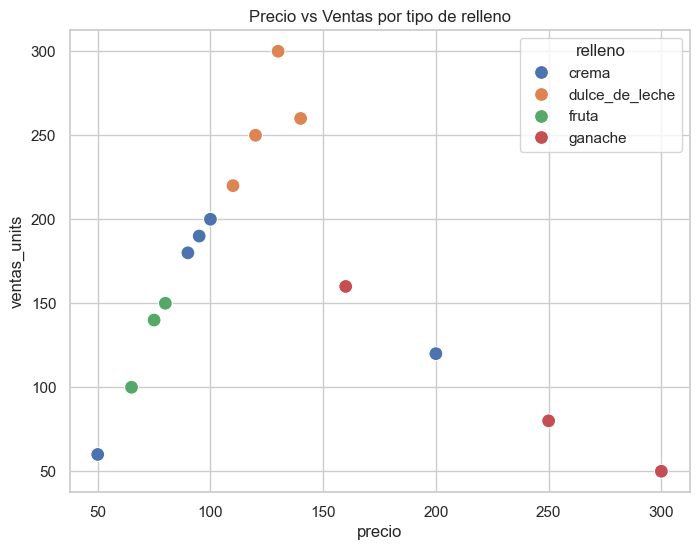

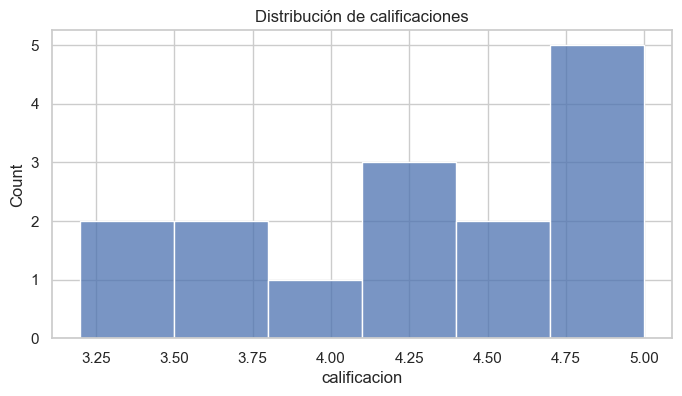

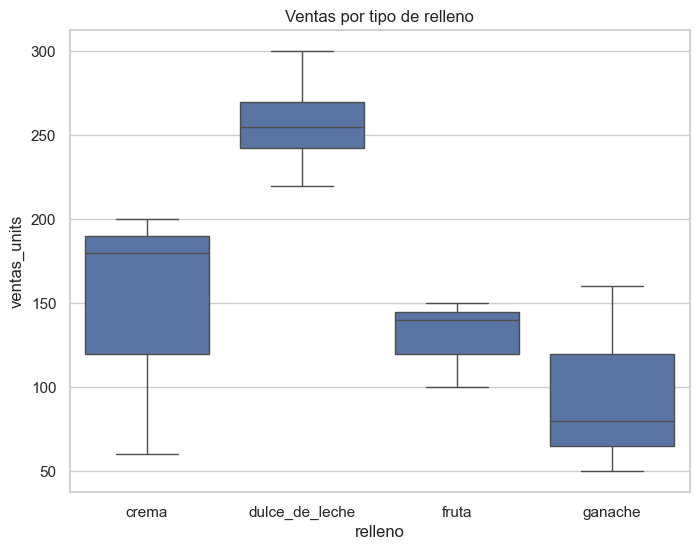

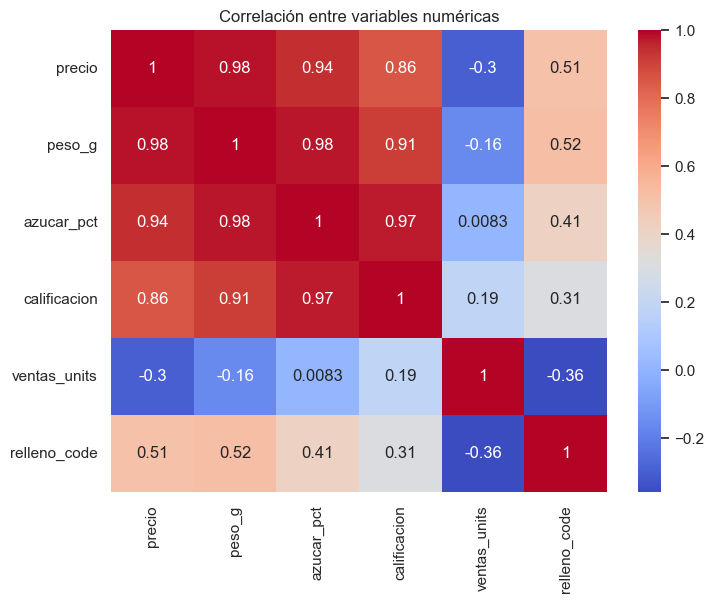

In [4]:
# Visualizaciones exploratorias
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='precio', y='ventas_units', hue='relleno', s=100)
plt.title('Precio vs Ventas por tipo de relleno')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['calificacion'], bins=6, kde=False)
plt.title('Distribución de calificaciones')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='relleno', y='ventas_units')
plt.title('Ventas por tipo de relleno')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()


## Clustering (KMeans)
Se usa escalado y se prueba el codo para seleccionar k

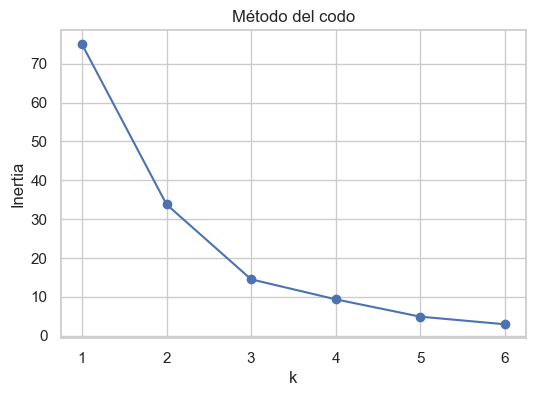

In [5]:
# Selección de features numéricas para clustering
features = ['precio','peso_g','azucar_pct','calificacion','ventas_units']
X = df[features].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Codo (inertia)
ks = range(1,7)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Método del codo')
plt.xticks(ks)
plt.show()


In [6]:
# Elegir k (ej: 3) y entrenar KMeans
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(Xs)
print('Silhouette score:', silhouette_score(Xs, df['cluster']))
print('Cluster counts:')
print(df['cluster'].value_counts())


Silhouette score: 0.4686542513294386
Cluster counts:
cluster
0    8
2    4
1    3
Name: count, dtype: int64


In [7]:
# Mostrar centroide en escala original (inversa)
centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
centers_df


,precio,peso_g,azucar_pct,calificacion,ventas_units
0,118.125,47.125,30.125000,4.400000,220.000000
1,250.000,70.000,37.666667,4.966667,83.333333
2,67.500,33.250,22.750000,3.500000,112.500000


In [8]:
# Comparar clusters vs relleno
ct = pd.crosstab(df['cluster'], df['relleno'])
ct


relleno,crema,dulce_de_leche,fruta,ganache
cluster,,,,
0,3,4,0,1
1,1,0,0,2
2,1,0,3,0


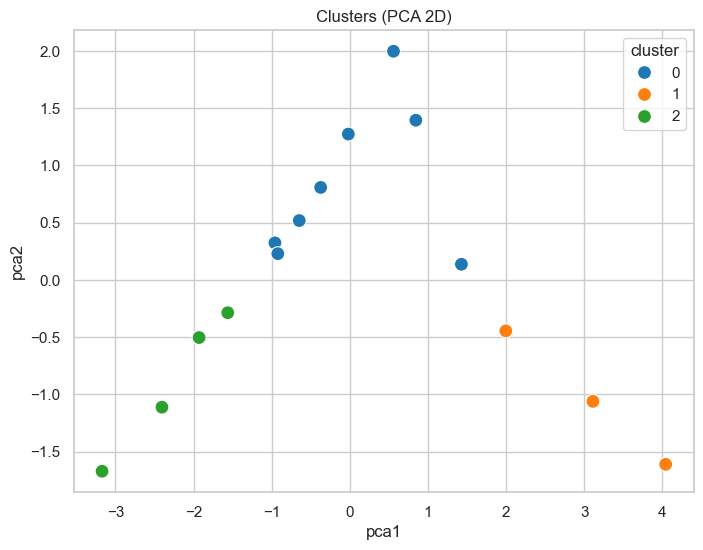

In [9]:
# Visualizar clusters en 2D con PCA
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)
df['pca1'] = Xp[:,0]
df['pca2'] = Xp[:,1]
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10', s=100)
plt.title('Clusters (PCA 2D)')
plt.show()


In [10]:
# Exportar resultados agregados y asignaciones
df.to_csv('alfajores_analisis_resultados.csv', index=False)
print('Exportado alfajores_analisis_resultados.csv')


Exportado alfajores_analisis_resultados.csv


## Conclusiones breves
Se observaron agrupamientos que correlacionan parcialmente con el tipo de relleno. El análisis repetible está guardado en alfajores_analisis_resultados.csv.